In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from pathlib import Path
from scipy.stats import shapiro
import statsmodels.api as sm
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines import CoxPHFitter
from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_curve, auc
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np

# Set up logging for tracking and debugging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


def read_files(clinical_file: str, bca_file: str, header: int = 1):
    """
    Reads the clinical data file and the BCA Excel file (all sheets) into DataFrames.
    
    Parameters:
        clinical_file (str): File path to the clinical data Excel file.
        bca_file (str): File path to the BCA Excel file.
        header (int): The header row index for the BCA sheets (default is 1).
    
    Returns:
        tuple: (df_clinical, sheets_dict)
            - df_clinical: DataFrame with clinical data.
            - sheets_dict: Dictionary of DataFrames from each sheet in the BCA file.
    """
    df_clinical = pd.read_excel(clinical_file)
    sheets_dict = pd.read_excel(bca_file, sheet_name=None, header=header)
    return df_clinical, sheets_dict

def process_and_merge(df_clinical: pd.DataFrame, sheets_dict: dict) -> pd.DataFrame:
    """
    Processes the BCA sheets by finding common IDs, filtering, renaming columns, merging,
    standardizing column names, and finally merging with the clinical data.
    
    parameters:
        df_clinical (pd.DataFrame): Clinical data DataFrame.
        sheets_dict (dict): Dictionary of DataFrames from the BCA file.
    
    returns:
        pd.DataFrame: The final merged DataFrame.
    """
    # identify common IDs across all BCA sheets.
    id_sets = {sheet: set(df['ID']) for sheet, df in sheets_dict.items()}
    common_ids = set.intersection(*id_sets.values())


    # filter each sheet to include only rows with common IDs.
    sheets_dict = {sheet: df[df['ID'].isin(common_ids)].copy() for sheet, df in sheets_dict.items()}
    
    # add a suffix to each column 
    for sheet, df in sheets_dict.items():
        df.rename(columns=lambda x: f"{x}_{sheet}" if x != 'ID' else x, inplace=True)
    
    # merge all BCA DataFrames on 'ID' using inner joins.
    merged_df = None
    for df in sheets_dict.values():
        if merged_df is None:
            merged_df = df
        else:
            merged_df = pd.merge(merged_df, df, on='ID', how='inner')
    
    # replace spaces with underscores and convert to lowercase.
    merged_df.columns = merged_df.columns.str.replace(' ', '_').str.lower()
    df_clinical.columns = df_clinical.columns.str.replace(' ', '_').str.lower()
    
    # Merge the BCA data with the clinical data on 'id'.
    final_df = pd.merge(merged_df, df_clinical, on='id', how='inner')
    return final_df

def save_file(df: pd.DataFrame, output_file_path: str):
    """
  
    Parameters:
        df (pd.DataFrame): The DataFrame to save.
        output_file_path (str): The path where the file will be saved.
    """
    try:
        df.to_excel(output_file_path, index=False)
        print(f"File saved successfully: {output_file_path}")
    except Exception as e:
        print(f"Error saving file: {e}")


def impute_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Impute missing values using IterativeImputer (MICE-like) for continuous variables.
    """
    def drop_columns(df: pd.DataFrame) -> pd.DataFrame:
        """
        drop columns with 100% missing values.
        """
        COLUMNS_DROP = [
        "date_of_birth", "pat_deathday", "end_of_follow-up_",
        "ct-scan_(intern/extern)", "layer_thickness_(mm)", "non-contrast_phase_(yes/no)",
        "arterial_resection_(yes/no)", "arterial_reconstruction_(yes/no)",
        "progression-free_survival_in_months_from_diagnosis",
        "progression_during_follow-up_(yes,no)", "site_of_progression"
        ]
        drop_cols = [col for col in COLUMNS_DROP if col in df.columns]
        if drop_cols:
            df = df.drop(columns=drop_cols)
        return df
    #drop columns with no data
    df = drop_columns(df)
    
  
    continuous_vars = [
        "whole_scan_bone_density_(mean_hu)",
        "abdominal_cavity_bone_density_(mean_hu)",
        "whole_scan_muscle_volume_(mean)",
        "abdominal_cavity_muscle_volume_(mean)",
        "whole_scan_total_adipose_tissue_vol_(mean)",
        "abdominal_cavity_total_adipose_tissue_vol_(mean)",
        "whole_scan_intramusc._adipose_tissu_(mean)",
        "abdominal_cavity_intramusc._adipose_tissu_(mean)",
        "whole_scan_subcutaneous_adip._tissu_(mean)",
        "abdominal_cavity_subcutaneous_adip._tissu_(mean)",
        "whole_scan_visceral_adipose_tissue__(mean)",
        "abdominal_cavity_visceral_adipose_tissue__(mean)",
        "whole_scan_pericardial_adipose_tiss_(mean)",
        "abdominal_cavity_pericardial_adipose_tiss_(mean)",
        "tumor_size_(mm)_",
        "number_of_locoregional_lymph_nodes_",
        "ca19-9_before_surgery",
        "cea_before_surgery"
    ]
    

    # make sure cols exist in the DataFrame
    continuous_vars = [col for col in continuous_vars if col in df.columns]
    
    # build pipelines for different variable types
    continuous_pipeline = Pipeline(steps=[
        ('iter_imputer', IterativeImputer(random_state=42))
    ])
    
  
    
    # Combine pipelines with ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('cont', continuous_pipeline, continuous_vars),
        ],
        remainder='passthrough'  # keep  remaining columns
    )
    
    logger.info("Starting imputation")
    imputed_array = preprocessor.fit_transform(df)
    
   
    remainder_cols = [col for col in df.columns if col not in continuous_vars]
    all_cols = continuous_vars + remainder_cols
    df_imputed = pd.DataFrame(imputed_array, columns=all_cols)
    
    logger.info("imputation completed")
    return df_imputed


def imputation_check(df_original: pd.DataFrame, df_imputed: pd.DataFrame, variable: str) :
    """
    sensitivy check comparing distribution of variables and ditribution of imputed values
    """
    
    # Extract observed values from the original data (non-missing) 
    observed = df_original[variable].dropna()

    # Extract the full imputed data for the same variable
    imputed = df_imputed[variable]

    # Plotting the distributions
    plt.figure(figsize=(10, 6))
    sns.kdeplot(observed, label='Observed', shade=True)
    sns.kdeplot(imputed, label='Imputed', shade=True)
    plt.title(f'Distribution Comparison for {variable}')
    plt.xlabel(variable)
    plt.legend()
    plt.show()

def assess_normality(data: pd.Series, variable_name: str) -> dict:
    """
    asess the normal distribution of a variable using the Shapiroo-Wilk test.
    Parameters:
    -----------
    data : pd.Series
        seriees containing the data for the variable.
    variable_name : str
        (for logging and reporting
    
    Returns:
    --------
    dict
        dictionarry with the variable name, test statistic, and p-value.
        
    """
    # test requires complete cases.
    data_clean = data.dropna()
    
    try:
        statistic, p_value = shapiro(data_clean)
        return {"variable": variable_name, "statistic": statistic, "p_value": p_value}
    except Exception as e:
        logger.error(f"Error performing Shapiro-Wilk test for {variable_name}: {e}")
        return {"variable": variable_name, "statistic": None, "p_value": None, "error": str(e)}

def run_normality_tests(df: pd.DataFrame, variables: list) -> pd.DataFrame:
    """
    helper func. to run normality tests
    
    Parameters:
    -----------
    df : pd.DataFrame
        The DataFrame containing the variables.
    variables : list
        a lst of column names to test 
    
    Returns:
    --------
    pd.DataFrame
        A DataFrame summarizing test resultss
    """
    results = []
    for var in variables:
        if var in df.columns:
            result = assess_normality(df[var], var)
            results.append(result)
        else:
            logger.warning(f"Variable '{var}' not found in the DataFrame.")
    return pd.DataFrame(results)

def plot_qq(data: pd.Series, variable_name: str) -> None:
    """
    genrate a Q-Q plot f

    Parameters:
    -----------
    data : pd.Series
        data for which to generate theplot.
    variable_name : str
        (used for title and file naming).
  
    """
    # test requires complete dataa
    data_clean = data.dropna()
    

    fig = plt.figure()
    ax = fig.add_subplot(111)
    sm.qqplot(data_clean, line='s', ax=ax)
    ax.set_title(f"Q-Q Plot for {variable_name}")
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")
    plt.tight_layout()
    
    plt.show()

def create_overview_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    creat an overview table sumarising the distribution of all variables in the DataFrame.
    for numeric variables, summary statistics include count, mean, std, min, quartiles, and max.
    For categorical variables, summary statistics include count, unique, top (most frequent), and frequency.
    
    
    Parameters:
    -----------
    df : pd.DataFrame
        imput DataFrame 
    
    Returns:
    --------
    pd.DataFrame
        summary DataFrame
    """
    summary_rows = []
    total_rows = len(df)
    
    for col in df.columns:
        col_data = df[col]
        missing_count = col_data.isnull().sum()
        missing_pct = (missing_count / total_rows) * 100
        
        # For numeric variables, use describe() to get summary statistics.
        if pd.api.types.is_numeric_dtype(col_data):
            desc = col_data.describe()
            row = {
                "Variable": col,
                "Type": "Numeric",
                "Count": desc.get("count", np.nan),
                "Missing": missing_count,
                "Missing (%)": round(missing_pct, 2),
                "Mean": round(desc.get("mean", np.nan), 2),
                "Std": round(desc.get("std", np.nan), 2),
                "Min": desc.get("min", np.nan),
                "25%": desc.get("25%", np.nan),
                "50%": desc.get("50%", np.nan),
                "75%": desc.get("75%", np.nan),
                "Max": desc.get("max", np.nan),
                "Unique": np.nan,
                "Top": np.nan,
                "Freq": np.nan
            }
        # For categorical variables, capture count, unique values, most frequent value, and its frequency.
        else:
            desc = col_data.describe()
            row = {
                "Variable": col,
                "Type": "Categorical",
                "Count": desc.get("count", np.nan),
                "Missing": missing_count,
                "Missing (%)": round(missing_pct, 2),
                "Mean": np.nan,
                "Std": np.nan,
                "Min": np.nan,
                "25%": np.nan,
                "50%": np.nan,
                "75%": np.nan,
                "Max": np.nan,
                "Unique": desc.get("unique", np.nan),
                "Top": desc.get("top", np.nan),
                "Freq": desc.get("freq", np.nan)
            }
        
        summary_rows.append(row)
    
    overview_df = pd.DataFrame(summary_rows)
    return overview_df

def preprocess_survival_data(df: pd.DataFrame, time_col: str, event_col: str, therapy_col: str) -> pd.DataFrame:
    """
    Preprocess the survival dataset:
    Convert the time col to numeric. convert the event col to binary convert the therapy indicator to binary.
    
    Parameters:
    -----------
    df : pd.DataFrame
         input DataFrame.
    time_col : str
        col name for time-toevent
    event_col : str
        col name for event indicator
    therapy_col : str
        col name for therapy indicator
    
    Returns:
    --------
    pd.DataFrame
        Processed datframe
    """
    # make sure time column is numeric.
    df[time_col] = pd.to_numeric(df[time_col], errors='coerce')
    
    if not pd.api.types.is_numeric_dtype(df[event_col]):
        df[event_col] = df[event_col].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0)
    
    # convert the therapy column if it is not already numeric (fixing bug)
    if not pd.api.types.is_numeric_dtype(df[therapy_col]):
        df[therapy_col] = df[therapy_col].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0)
    
    
    return df

def plot_km_curve(df: pd.DataFrame, time_col: str, event_col: str, therapy_col: str, therapy_label: str, save_path: Path = None):
    """
    generates Kaplan-Meier survival curves for two groups defined by the therapy variable,

    
    

    Returns:
    --------
    results : lifelines.statistics.StatisticalResult
        result of the log-rank test 
    """
    kmf = KaplanMeierFitter()
    
    # Split the data into two groups.
    group_yes = df[df[therapy_col] == 1]
    group_no = df[df[therapy_col] == 0]
    
    plt.figure(figsize=(10, 6))
    
    
    kmf.fit(durations=group_yes[time_col], event_observed=group_yes[event_col], label=f"{therapy_label}: Yes")
    ax = kmf.plot(ci_show=True)
    
   
    kmf.fit(durations=group_no[time_col], event_observed=group_no[event_col], label=f"{therapy_label}: No")
    kmf.plot(ax=ax, ci_show=True)
    
    plt.title(f"Kaplan-Meier Survival Curve by {therapy_label}")
    plt.xlabel("Time (months)")
    plt.ylabel("Survival Probability")
    plt.legend()
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
        logger.info(f"Kaplan-Meier plot saved to {save_path}")
    
    plt.show()
    
    # Conduct a log-rank test to compare the survival curves.
    results = logrank_test(
        group_yes[time_col],
        group_no[time_col],
        event_observed_A=group_yes[event_col],
        event_observed_B=group_no[event_col]
    )
    logger.info(f"Log-rank test p-value for {therapy_label}: {results.p_value:.4f}")
    
    return results


def preprocess_cox_data(df: pd.DataFrame, time_col: str, event_col: str, therapy_cols: list, additional_covariates: list = None) -> pd.DataFrame:

    # drop rows with missing values
    df = df.dropna(subset=[time_col, event_col] + therapy_cols + (additional_covariates if additional_covariates else []))
    
    # time column to numeric.
    df[time_col] = pd.to_numeric(df[time_col], errors='coerce')
    
    # event indicator to numeric if not already.
    if not pd.api.types.is_numeric_dtype(df[event_col]):
        df[event_col] = df[event_col].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0)
    
    #therapy columns to numeric 
    for col in therapy_cols:
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0)
    
    
    cols = [time_col, event_col] + therapy_cols
    if additional_covariates:
        cols.extend(additional_covariates)
    df_cox = df[cols].copy()
    
    # Ccategorical covariates into dummy 
    if additional_covariates:
        df_cox = pd.get_dummies(df_cox, columns=additional_covariates, drop_first=True)
    
    return df_cox

def fit_cox_model(df: pd.DataFrame, time_col: str, event_col: str) -> CoxPHFitter:

    cph = CoxPHFitter()
    cph.fit(df, duration_col=time_col, event_col=event_col)
    cph.print_summary()  # Print hazard ratios, confidence intervals, and p-values.
    return cph

def compare_body_composition_by_therapy(df: pd.DataFrame, therapy_col: str, bc_vars: list) -> None:
    """
    cmpare body composition vars betw groups defined by  therapy using  Mann-Whitney U test.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFramee containing body composition and therapy variables
    therapy_col : str
        Name of  therapy variable
    bc_vars : list
        List of body composition variables
    
    """
    # unique values and counts for therapy variable (bug)
    unique_vals = df[therapy_col].unique()
  
    
    for var in bc_vars:
        try:
            col_numeric = pd.to_numeric(df[var], errors='coerce')
            
            group_yes = col_numeric[df[therapy_col] == 1].dropna()
            group_no  = col_numeric[df[therapy_col] == 0].dropna()
            
            n_yes = group_yes.shape[0]
            n_no  = group_no.shape[0]
            
            # Perform the Mann-Whitney U test.
            stat, p_value = mannwhitneyu(group_yes, group_no, alternative='two-sided')
            logger.info(f"{var} - Mann-Whitney U test statistic: {stat:.4f}, p-value: {p_value:.4f}")
        except Exception as e:
            logger.error(f"Error testing {var} for {therapy_col}: {e}")

def calculate_ratio(df: pd.DataFrame, intramuscular_col: str, muscle_col: str) -> pd.DataFrame:

    
    df[intramuscular_col] = pd.to_numeric(df[intramuscular_col], errors='coerce')
    df[muscle_col] = pd.to_numeric(df[muscle_col], errors='coerce')
    
    df['im_to_muscle_ratio'] = df[intramuscular_col] / df[muscle_col]
    logger.info("Calculated intramuscular adipose to muscle ratio.")
    return df

def roc_analysis_for_ratio(df: pd.DataFrame, ratio_col: str, outcome_col: str):
    
    # Drop missing values
    data = df[[ratio_col, outcome_col]].dropna()
    y_true = data[outcome_col].values
    y_scores = data[ratio_col].values
    
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    # Calculate Youden's index and select optimal threshold
    youdens_index = tpr - fpr
    optimal_idx = np.argmax(youdens_index)
    optimal_threshold = thresholds[optimal_idx]
    logger.info(f"Optimal cutoff for {ratio_col} is {optimal_threshold:.4f}")
    
    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', label=f'Optimal cutoff = {optimal_threshold:.2f}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Ratio Predicting Complications')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    
    return fpr, tpr, thresholds, optimal_threshold

def logistic_regression_adjusted(df: pd.DataFrame, outcome_col: str, ratio_col: str, gender_col: str):

    # Ensure the outcome is numeric
    df[outcome_col] = pd.to_numeric(df[outcome_col], errors='coerce')
    # For gender, assume it's categorical; if needed, convert it.
    # We'll use a formula with C(gender_col) to indicate categorical.
    formula = f"{outcome_col} ~ {ratio_col} + C({gender_col})"
    model = smf.logit(formula=formula, data=df).fit(disp=False)
    print(model.summary())
    return model

def univariable_cox_analysis(df: pd.DataFrame, time_col: str, event_col: str, predictor: str) -> dict:
    
    cph = CoxPHFitter()
   
    df_temp = df[[time_col, event_col, predictor]].dropna().copy()
    
    
    df_temp[time_col] = pd.to_numeric(df_temp[time_col], errors='coerce')
    df_temp[event_col] = pd.to_numeric(df_temp[event_col], errors='coerce')
    df_temp[predictor] = pd.to_numeric(df_temp[predictor], errors='coerce')
    
    try:
        cph.fit(df_temp, duration_col=time_col, event_col=event_col)
        
        summary = cph.summary.loc[predictor]
        hr = np.exp(summary['coef'])
        lower_ci = np.exp(summary['coef lower 95%'])
        upper_ci = np.exp(summary['coef upper 95%'])
        p_value = summary['p']
        concordance = cph.concordance_index_
    except Exception as e:
        logger.error(f"Error analyzing predictor {predictor}: {e}")
        hr, lower_ci, upper_ci, p_value, concordance = np.nan, np.nan, np.nan, np.nan, np.nan

    return {
        "Predictor": predictor,
        "HR": hr,
        "95% CI Lower": lower_ci,
        "95% CI Upper": upper_ci,
        "p-value": p_value,
        "Concordance": concordance
    }

def analyze_body_composition(df: pd.DataFrame, time_col: str, event_col: str, predictors: list) -> pd.DataFrame:

    results = []
    for predictor in predictors:
        result = univariable_cox_analysis(df, time_col, event_col, predictor)
        results.append(result)
    return pd.DataFrame(results)

def plot_adipose(df, adipose_vars):
    # Melt the DataFrame to long format.
    df_melted = pd.melt(df, id_vars=['sex'], value_vars=adipose_vars,
                        var_name='Adipose_Type', value_name='Volume')

    # Convert the Volume column to numeric (in case it isn't already).
    df_melted['Volume'] = pd.to_numeric(df_melted['Volume'], errors='coerce')

    # Create a violin plot with box plot overlay, stratified by gender.
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Adipose_Type', y='Volume', hue='sex', data=df_melted, split=True,
                inner='box', palette='Set2')
    plt.title("Distribution of Adipose Tissue Compartments by Gender")
    plt.xlabel("Adipose Tissue Compartment")
    plt.ylabel("Volume")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [2]:
# get currrent working directory
cwd = os.getcwd()

# define file paht
clinical_file = os.path.join(cwd, 'PDAC_Patient_clinical_data.xlsx')
bca_file = os.path.join(cwd, 'PDAC_Patient_BCA_data.xlsx')


df_clinical, sheets_dict = read_files(clinical_file, bca_file, header=1)

# Process and merge data.
merged_df = process_and_merge(df_clinical, sheets_dict)

# save merged data.
output_file = os.path.join(cwd, 'PDAC_Patient_clinical_BCA.xlsx')
save_file(merged_df, output_file)

File saved successfully: /Users/mofty/Desktop/UKSH_analysis_final/PDAC_Patient_clinical_BCA.xlsx


INFO:__main__:Starting imputation
INFO:__main__:imputation completed
/var/folders/zh/hjx5tthx15ngn1bxz79cdd6w0000gn/T/ipykernel_20447/2287327023.py:187: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(observed, label='Observed', shade=True)
/var/folders/zh/hjx5tthx15ngn1bxz79cdd6w0000gn/T/ipykernel_20447/2287327023.py:188: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(imputed, label='Imputed', shade=True)


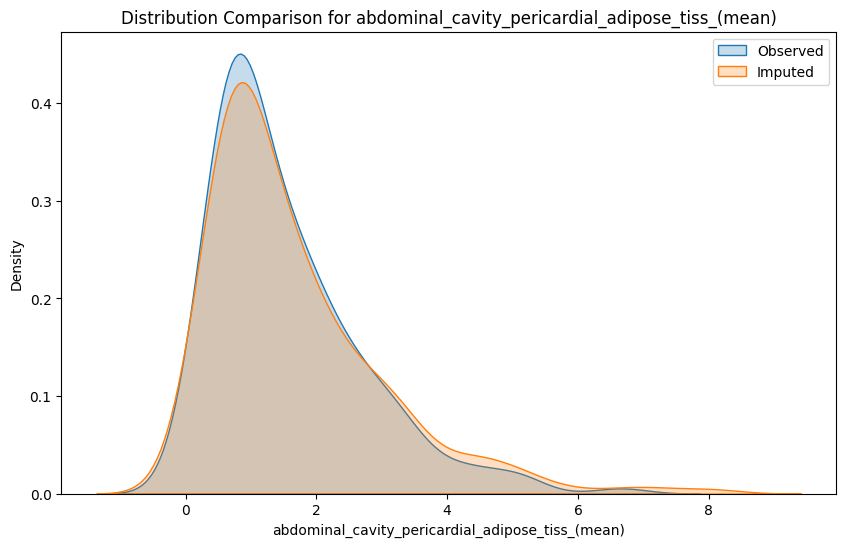

In [3]:
df_imputed = impute_data(merged_df)

imputation_check(merged_df, df_imputed, 'abdominal_cavity_pericardial_adipose_tiss_(mean)' )


File saved successfully: /Users/mofty/Desktop/UKSH_analysis_final/normality_test.xlsx


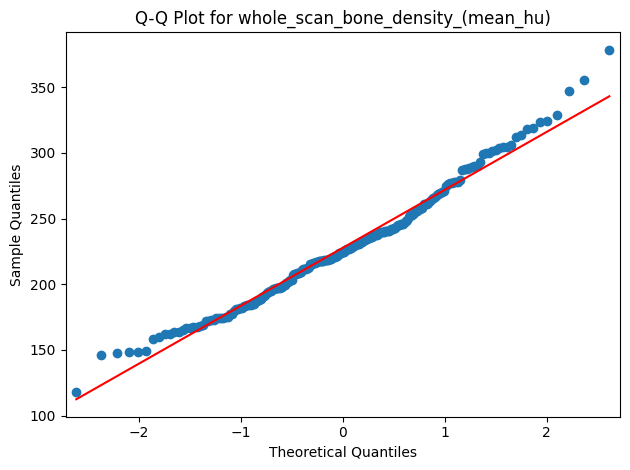

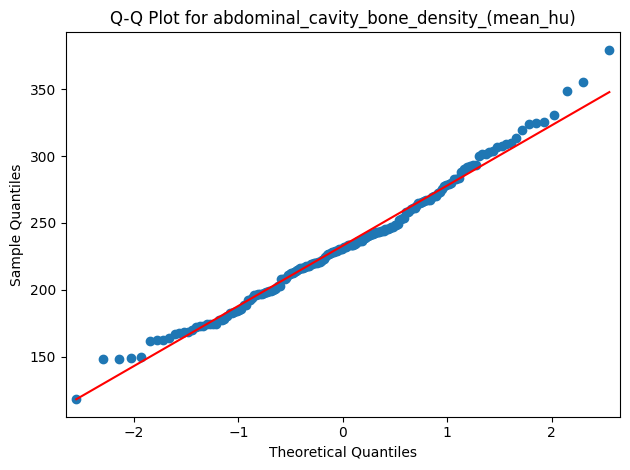

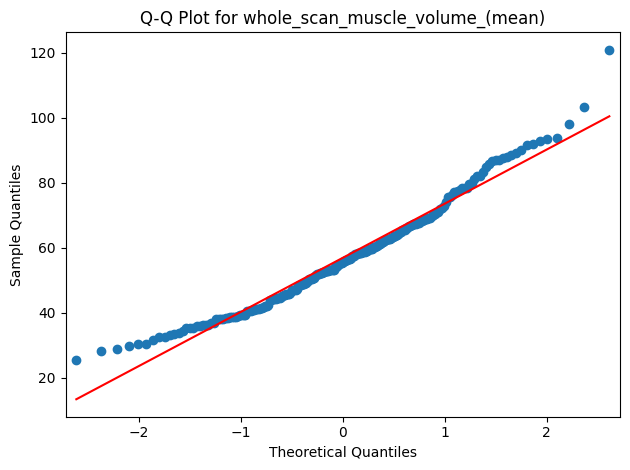

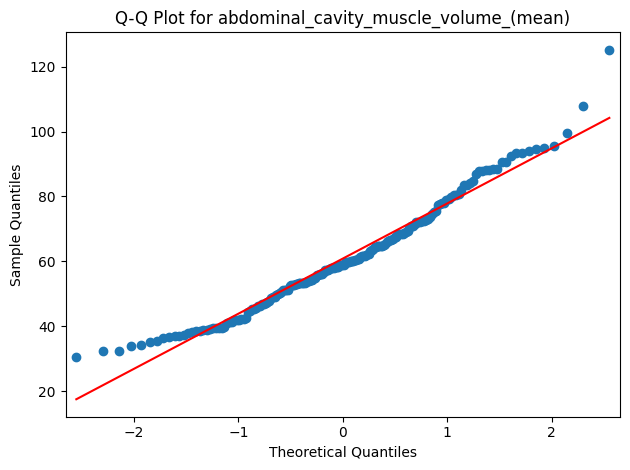

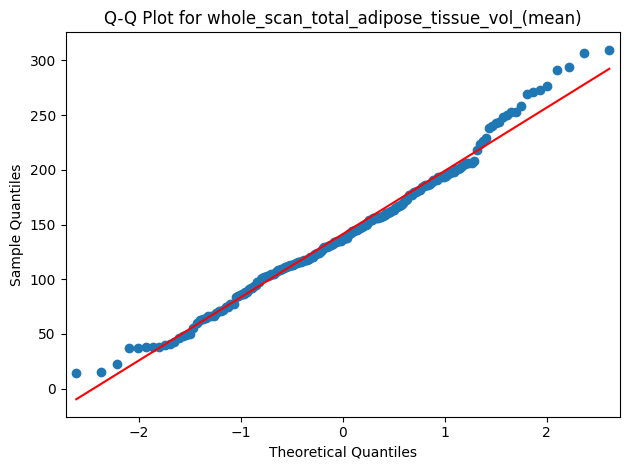

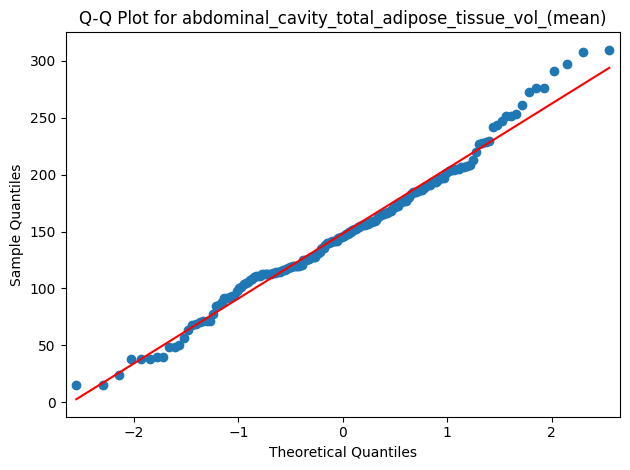

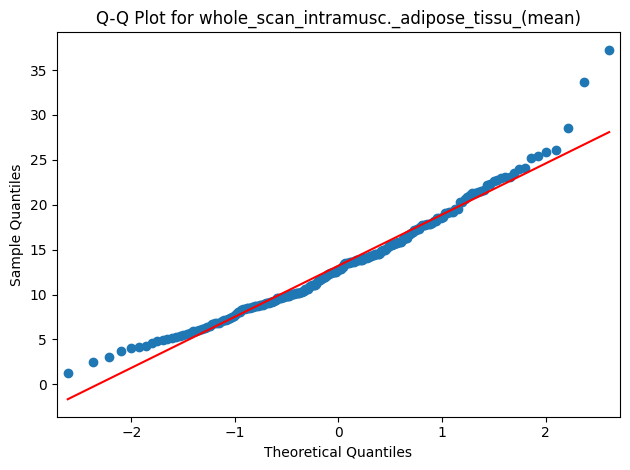

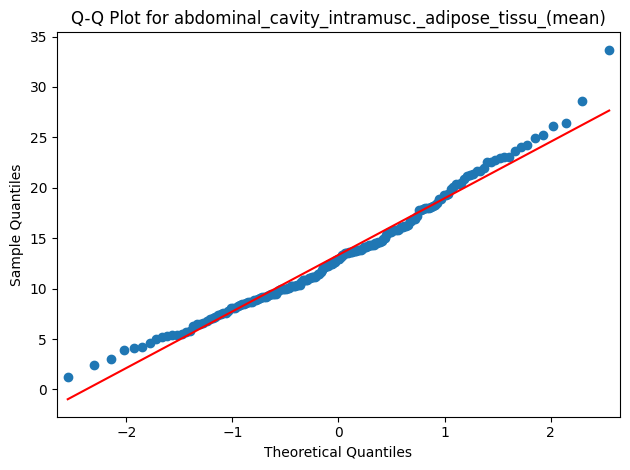

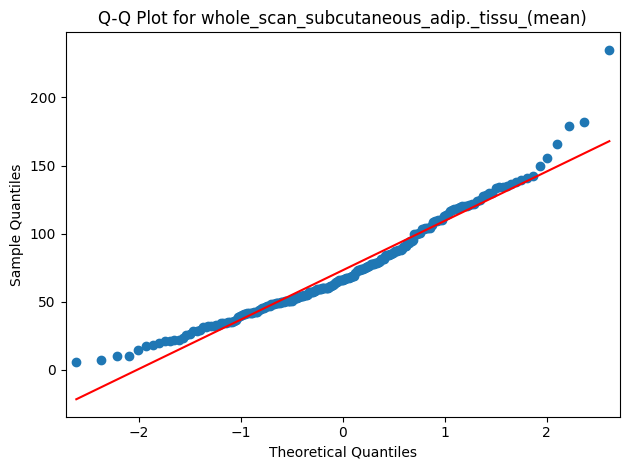

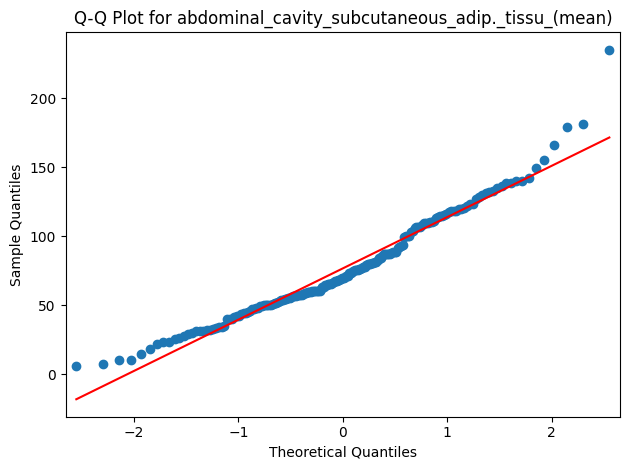

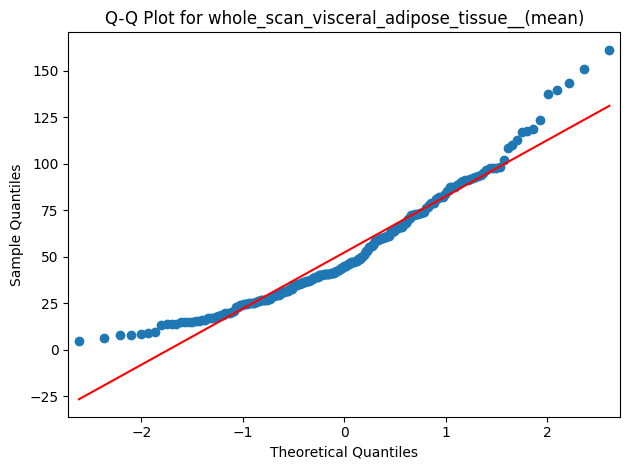

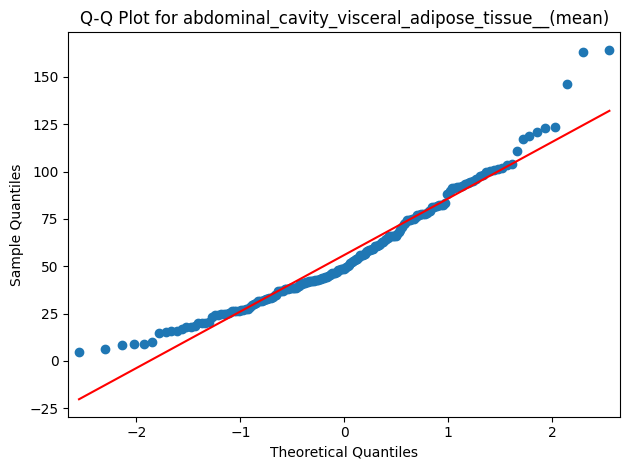

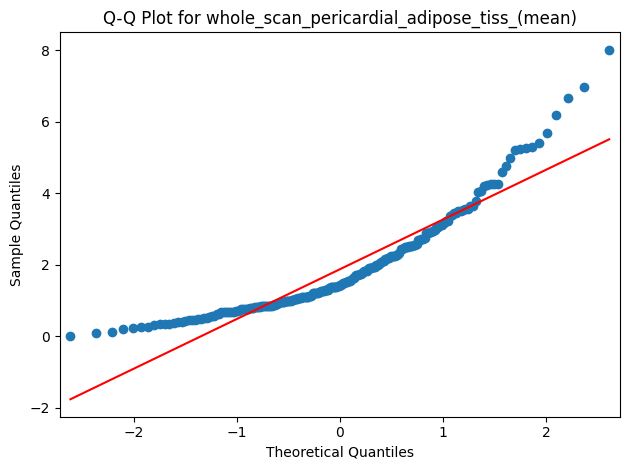

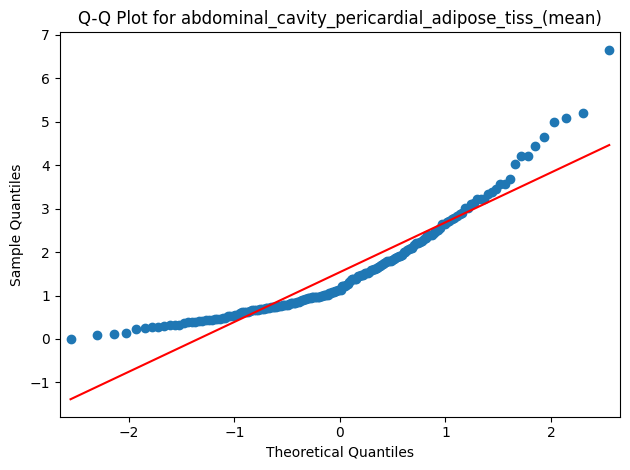

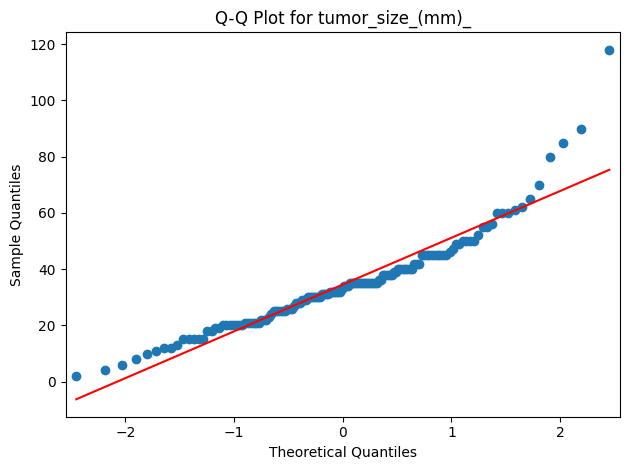

In [5]:
variables_to_test = [
        "whole_scan_bone_density_(mean_hu)",
        "abdominal_cavity_bone_density_(mean_hu)",
        "whole_scan_muscle_volume_(mean)",
        "abdominal_cavity_muscle_volume_(mean)",
        "whole_scan_total_adipose_tissue_vol_(mean)",
        "abdominal_cavity_total_adipose_tissue_vol_(mean)",
        "whole_scan_intramusc._adipose_tissu_(mean)",
        "abdominal_cavity_intramusc._adipose_tissu_(mean)",
        "whole_scan_subcutaneous_adip._tissu_(mean)",
        "abdominal_cavity_subcutaneous_adip._tissu_(mean)",
        "whole_scan_visceral_adipose_tissue__(mean)",
        "abdominal_cavity_visceral_adipose_tissue__(mean)",
        "whole_scan_pericardial_adipose_tiss_(mean)",
        "abdominal_cavity_pericardial_adipose_tiss_(mean)",
        'tumor_size_(mm)_'
        
]

df_normality_results = run_normality_tests(df_imputed, variables_to_test)
output_file = os.path.join(cwd, 'normality_test.xlsx')
save_file(df_normality_results, output_file)


for var in variables_to_test:
        if var in merged_df.columns:
            plot_qq(merged_df[var], var)
        else:
            logger.warning(f"Variable '{var}' not found in the DataFrame.")


INFO:__main__:Kaplan-Meier plot saved to KM_neoadjuvant.png


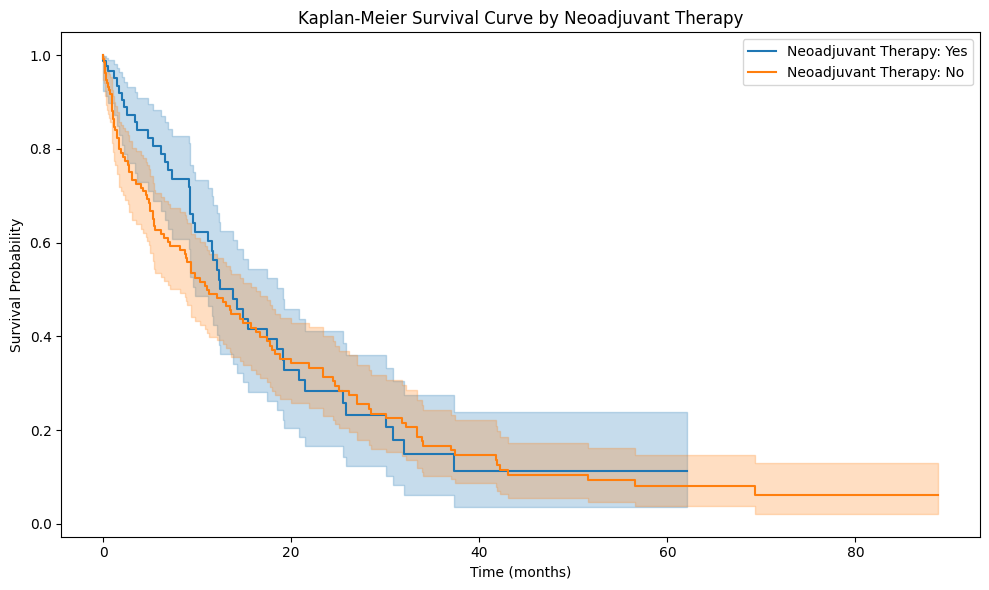

INFO:__main__:Log-rank test p-value for Neoadjuvant Therapy: 0.4326
INFO:__main__:Kaplan-Meier plot saved to KM_neoadjuvant.png


NeoAdjuvant Log-rank test p-value: 0.4326454246507908


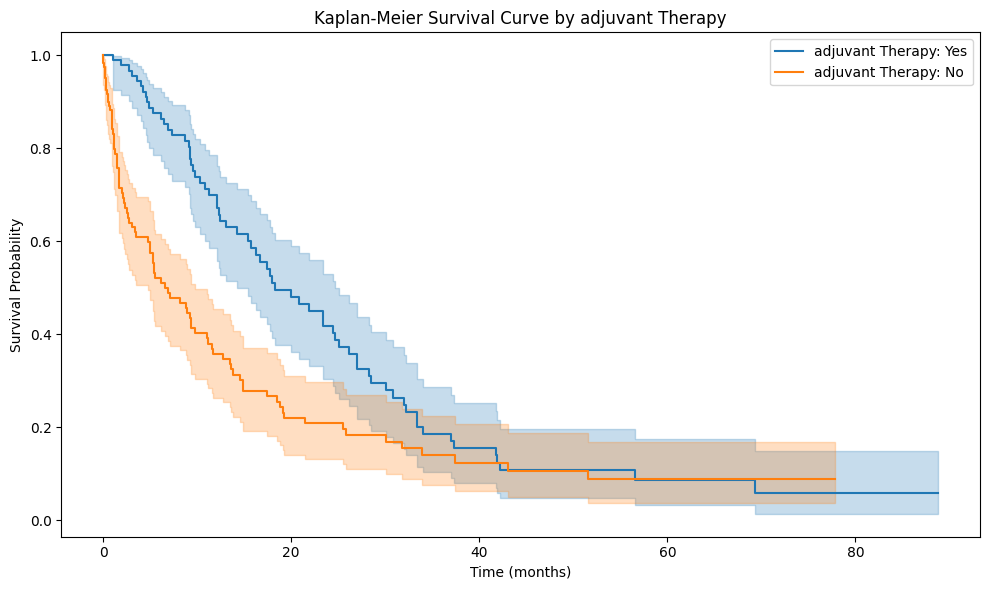

INFO:__main__:Log-rank test p-value for adjuvant Therapy: 0.0004


Adjuvant Log-rank test p-value: 0.00038864754775510467


In [6]:
time_col = 'overall_survival_in_months_from_diagnosis'
event_col = 'death_during_follow-up'
therapy_col = 'neoadjuvant_therapy_(yes/no)'
therapy_label = 'Neoadjuvant Therapy'


# Preprocess the data to ensure proper types.
df_survival = preprocess_survival_data(df_imputed, time_col, event_col, therapy_col)
results = plot_km_curve(df_survival, time_col, event_col, therapy_col, therapy_label, save_path=Path("KM_neoadjuvant.png"))
print("NeoAdjuvant Log-rank test p-value:", results.p_value)

therapy_col = 'adjuvant_therapy_(yes/no)__'
therapy_label = 'adjuvant Therapy'

df_survival = preprocess_survival_data(df_imputed, time_col, event_col, therapy_col)
results = plot_km_curve(df_survival, time_col, event_col, therapy_col, therapy_label, save_path=Path("KM_neoadjuvant.png"))
print("Adjuvant Log-rank test p-value:", results.p_value)


In [8]:

df_imputed = df_imputed.rename(columns={'sex_(male/female)': 'sex'})

time_col = 'overall_survival_in_months_from_diagnosis'
event_col = 'death_during_follow-up'
therapy_cols = ['neoadjuvant_therapy_(yes/no)', 'adjuvant_therapy_(yes/no)__']

additional_covariates = [
    'sex',
    'complications',
    'venous_invasion_yes/no_',
    't_(t-stage_pt_in_anderer_tabelle)',
    'grading',
]

# Preprcess data
df_cox = preprocess_cox_data(df_imputed, time_col, event_col, therapy_cols, additional_covariates)

# fit cox model.
cph_model = fit_cox_model(df_cox, time_col, event_col)




/var/folders/zh/hjx5tthx15ngn1bxz79cdd6w0000gn/T/ipykernel_20447/2287327023.py:434: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[time_col] = pd.to_numeric(df[time_col], errors='coerce')


<lifelines.CoxPHFitter: fitted with 149 total observations, 45 right-censored observations>
             duration col = 'overall_survival_in_months_from_diagnosis'
                event col = 'death_during_follow-up'
      baseline estimation = breslow
   number of observations = 149
number of events observed = 104
   partial log-likelihood = -412.61
         time fit was run = 2025-02-12 20:27:37 UTC

---
                                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                             
neoadjuvant_therapy_(yes/no)          0.06      1.06      0.26           -0.44            0.56                0.64                1.76
adjuvant_therapy_(yes/no)__          -0.52      0.60      0.21           -0.94           -0.10                0.39                0.90
sex_MALE                             -0.17      0.84      0.21           -0.59            0.25                0.56                1.28
complications_yes                    -0.18      0.83      0.24           -0.65            0.28                0.52                1.33
venous_invasion_yes/no__yes           0.05      1.05      0.23           -0.39            0.50                0.68                1.64
t_(t-stage_pt_in_anderer_tabelle)_T2  0.48      1.62      0.51           -0.52            1.49                0.59                4.43
t_(t-stage_pt_in_anderer_tabelle)_T3  0.55      1.74      0.45           -0.33            1.43                0.72                4.19
t_(t-stage_pt_in_anderer_tabelle)_T4  1.86      6.39      0.52            0.83            2.88                2.29               17.86
grading_G2                           -0.31      0.74      0.40           -1.10            0.48                0.33                1.62
grading_G3                            0.05      1.05      0.43           -0.80            0.90                0.45                2.47
grading_G4                            1.99      7.35      1.12           -0.20            4.19                0.82               66.20

                                      cmp to     z      p  -log2(p)
covariate                                                          
neoadjuvant_therapy_(yes/no)            0.00  0.24   0.81      0.30
adjuvant_therapy_(yes/no)__             0.00 -2.43   0.01      6.06
sex_MALE                                0.00 -0.79   0.43      1.23
complications_yes                       0.00 -0.77   0.44      1.18
venous_invasion_yes/no__yes             0.00  0.23   0.82      0.29
t_(t-stage_pt_in_anderer_tabelle)_T2    0.00  0.94   0.34      1.54
t_(t-stage_pt_in_anderer_tabelle)_T3    0.00  1.23   0.22      2.19
t_(t-stage_pt_in_anderer_tabelle)_T4    0.00  3.54 <0.005     11.29
grading_G2                              0.00 -0.76   0.45      1.17
grading_G3                              0.00  0.12   0.91      0.14
grading_G4                              0.00  1.78   0.08      3.73
---
Concordance = 0.64
Partial AIC = 847.21
log-likelihood ratio test = 28.39 on 11 df
-log2(p) of ll-ratio test = 8.47

In [9]:
body_composition_vars = [
    'abdominal_cavity_muscle_volume_(mean)',
    'abdominal_cavity_total_adipose_tissue_vol_(mean)',
    'abdominal_cavity_intramusc._adipose_tissu_(mean)',
    'abdominal_cavity_subcutaneous_adip._tissu_(mean)',
    'abdominal_cavity_visceral_adipose_tissue__(mean)',
    'whole_scan_muscle_volume_(mean)',
    'whole_scan_total_adipose_tissue_vol_(mean)',
    'whole_scan_intramusc._adipose_tissu_(mean)',
    'whole_scan_subcutaneous_adip._tissu_(mean)',
    'whole_scan_visceral_adipose_tissue__(mean)'
]

# Therapy variables to test.
therapy_vars = [ 'adjuvant_therapy_(yes/no)__', 'neoadjuvant_therapy_(yes/no)',]

for therapy in therapy_vars:
    logger.info(f"Comparing body composition by therapy variable: {therapy}")
    compare_body_composition_by_therapy(df_imputed, therapy, body_composition_vars)


INFO:__main__:Comparing body composition by therapy variable: adjuvant_therapy_(yes/no)__
INFO:__main__:abdominal_cavity_muscle_volume_(mean) - Mann-Whitney U test statistic: 6086.0000, p-value: 0.8603
INFO:__main__:abdominal_cavity_total_adipose_tissue_vol_(mean) - Mann-Whitney U test statistic: 6537.0000, p-value: 0.4464
INFO:__main__:abdominal_cavity_intramusc._adipose_tissu_(mean) - Mann-Whitney U test statistic: 6512.0000, p-value: 0.4781
INFO:__main__:abdominal_cavity_subcutaneous_adip._tissu_(mean) - Mann-Whitney U test statistic: 6333.0000, p-value: 0.7365
INFO:__main__:abdominal_cavity_visceral_adipose_tissue__(mean) - Mann-Whitney U test statistic: 6615.0000, p-value: 0.3555
INFO:__main__:whole_scan_muscle_volume_(mean) - Mann-Whitney U test statistic: 6445.0000, p-value: 0.5688
INFO:__main__:whole_scan_total_adipose_tissue_vol_(mean) - Mann-Whitney U test statistic: 6673.0000, p-value: 0.2961
INFO:__main__:whole_scan_intramusc._adipose_tissu_(mean) - Mann-Whitney U test stat

INFO:__main__:Calculated intramuscular adipose to muscle ratio.
INFO:__main__:Optimal cutoff for im_to_muscle_ratio is 0.1428


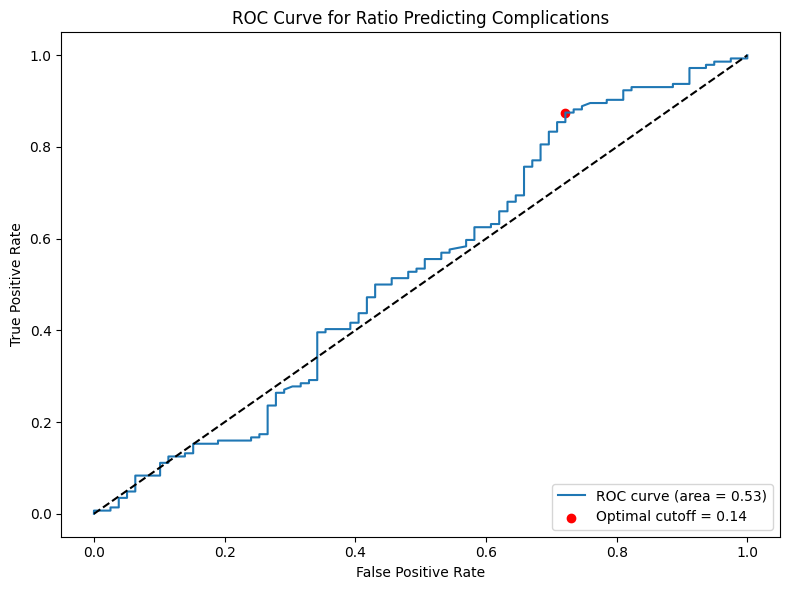

                           Logit Regression Results                           
Dep. Variable:          complications   No. Observations:                  223
Model:                          Logit   Df Residuals:                      220
Method:                           MLE   Df Model:                            2
Date:                Wed, 12 Feb 2025   Pseudo R-squ.:                 0.01133
Time:                        21:30:26   Log-Likelihood:                -143.32
converged:                       True   LL-Null:                       -144.96
Covariance Type:            nonrobust   LLR p-value:                    0.1936
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0617      0.391      0.158      0.875      -0.705       0.828
C(sex)[T.MALE]         0.5290      0.301      1.760      0.078      -0.060       1.118
im_to_muscle_ratio  

In [10]:
intramuscular_col = 'whole_scan_intramusc._adipose_tissu_(mean)'
muscle_col = 'whole_scan_muscle_volume_(mean)'
complication_col = 'complications'  # assuming this is binary or coded as yes/no
gender_col = 'sex'

# convert complication column to binary 
if not pd.api.types.is_numeric_dtype(df_imputed[complication_col]):
    df_imputed[complication_col] = df_imputed[complication_col].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0)

# Cclculate the ratio
df_imputed = calculate_ratio(df_imputed, intramuscular_col, muscle_col)

# unadjusted Roc analysis to find  cutoff
roc_analysis_for_ratio(df_imputed, 'im_to_muscle_ratio', complication_col)

#  logistic regression adjusting for gender
logistic_regression_adjusted(df_imputed, complication_col, 'im_to_muscle_ratio', gender_col)



In [11]:

time_col = "overall_survival_in_months_from_diagnosis"
event_col = "death_during_follow-up"

# Define candidate body composition predictors.
predictors = [
    'abdominal_cavity_muscle_volume_(mean)',
    'abdominal_cavity_total_adipose_tissue_vol_(mean)',
    'abdominal_cavity_intramusc._adipose_tissu_(mean)',
    'abdominal_cavity_subcutaneous_adip._tissu_(mean)',
    'abdominal_cavity_visceral_adipose_tissue__(mean)',
    'whole_scan_muscle_volume_(mean)',
    'whole_scan_total_adipose_tissue_vol_(mean)',
    'whole_scan_intramusc._adipose_tissu_(mean)',
    'whole_scan_subcutaneous_adip._tissu_(mean)',
    'whole_scan_visceral_adipose_tissue__(mean)'
]

# Run univariable Cox regression analyses.
results_df = analyze_body_composition(df_imputed, time_col, event_col, predictors)
logger.info("Univariable Cox regression analysis complete.")
print(results_df)

# Save the summary table to Excel.
output_file = Path("body_composition_survival_analysis.xlsx")
results_df.to_excel(output_file, index=False)


INFO:__main__:Univariable Cox regression analysis complete.


                                          Predictor        HR  95% CI Lower  \
0             abdominal_cavity_muscle_volume_(mean)  0.999231      0.990773   
1  abdominal_cavity_total_adipose_tissue_vol_(mean)  0.998895      0.995790   
2  abdominal_cavity_intramusc._adipose_tissu_(mean)  1.009345      0.977769   
3  abdominal_cavity_subcutaneous_adip._tissu_(mean)  0.998820      0.994188   
4  abdominal_cavity_visceral_adipose_tissue__(mean)  0.997817      0.991764   
5                   whole_scan_muscle_volume_(mean)  0.999914      0.990270   
6        whole_scan_total_adipose_tissue_vol_(mean)  0.999245      0.996380   
7        whole_scan_intramusc._adipose_tissu_(mean)  1.008180      0.978192   
8        whole_scan_subcutaneous_adip._tissu_(mean)  0.998943      0.994570   
9        whole_scan_visceral_adipose_tissue__(mean)  0.998804      0.993230   

   95% CI Upper   p-value  Concordance  
0      1.007760  0.859126     0.493386  
1      1.002009  0.486170     0.536169  
2      

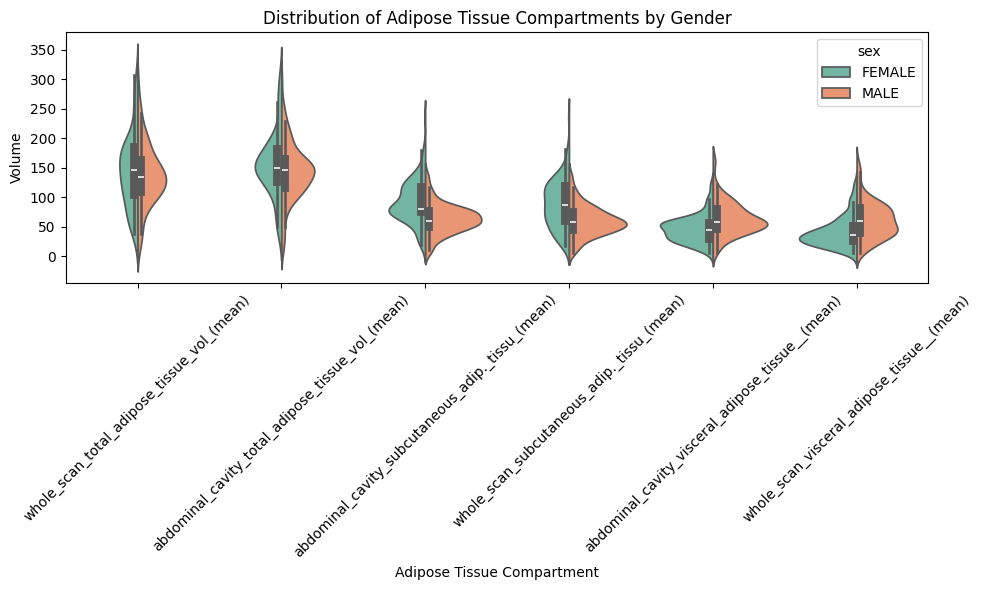

In [12]:


adipose_vars = [
    'whole_scan_total_adipose_tissue_vol_(mean)',
    'abdominal_cavity_total_adipose_tissue_vol_(mean)',

    'abdominal_cavity_subcutaneous_adip._tissu_(mean)',
    'whole_scan_subcutaneous_adip._tissu_(mean)',

    'abdominal_cavity_visceral_adipose_tissue__(mean)',
    'whole_scan_visceral_adipose_tissue__(mean)',
]    

plot_adipose(df_imputed, adipose_vars)

